In [28]:
import re
import string

import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Bidirectional, SpatialDropout1D, Dropout
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2

from gensim.models import Word2Vec

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

import pandas as pd
pd.options.mode.chained_assignment = None

# **Data Pre-Processing & Labeling**

##### 1. Drop Null value rows and duplicates

In [29]:
df = pd.read_csv('../dataset/movie_reviews.csv')

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.DataFrame'>
Index: 23820 entries, 0 to 25209
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   title    23820 non-null  str    
 1   content  23820 non-null  str    
 2   rating   23820 non-null  float64
dtypes: float64(1), str(2)
memory usage: 744.4 KB


##### 2. Combine review 'title' and 'content' into 'full_text'

In [30]:
df['full_text'] = df['title'] + ' ' + df['content']
df.info()

<class 'pandas.DataFrame'>
Index: 23820 entries, 0 to 25209
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      23820 non-null  str    
 1   content    23820 non-null  str    
 2   rating     23820 non-null  float64
 3   full_text  23820 non-null  str    
dtypes: float64(1), str(3)
memory usage: 930.5 KB


##### 3. Apply sentiment labelling according to review ratings
(1 - 4)  : Negative\
(5 - 6)  : Neutral\
(7 - 10) : Positive

In [31]:
def sentiment_labeling(rating):
    polarity = ''
    
    if rating <= 4:
        polarity = 'negative'
    elif rating >= 7:
        polarity = 'positive'
    else:
        polarity = 'neutral'
        
    return polarity

In [32]:
results = df['rating'].apply(sentiment_labeling)
df['polarity'] = results
df['polarity'].value_counts()

polarity
positive    11995
negative     8501
neutral      3324
Name: count, dtype: int64

##### 4. Apply data cleaning
Steps:
1. clean text (remove numbers, speial characters, new lines, punctuations, and spaces)
2. casefolding (lowercase)
3. tokenize
4. remove english stopwords
5. stemming
6. lemmatizing
7. convert back to whole string

In [33]:
def cleaning_text(text):
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove special characters
 
    text = text.replace('\n', ' ') # remove new lines
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove punctuations
    text = text.strip(' ') # trimming
    return text
 
def casefolding_text(text):
    text = text.lower()
    return text
 
def tokenizing_text(text):
    text = word_tokenize(text)
    return text
 
def stopword_text(text):
    listStopwords = set(stopwords.words('english'))
    listStopwords.update(listStopwords)
    filtered = [word for word in text if word not in listStopwords]
    return filtered
 
def stemming_text(text):
    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(word) for word in text]
    return stemmed

def lemming_text(text):
    lemmer = WordNetLemmatizer()
    lemmatized = [lemmer.lemmatize(word) for word in text]
    return lemmatized
 
def to_sentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [34]:
clean_df = df
clean_df['clean_text'] = clean_df['full_text'].apply(cleaning_text)
clean_df['casefold_text'] = clean_df['clean_text'].apply(casefolding_text)
clean_df['tokenized_text'] = clean_df['casefold_text'].apply(tokenizing_text)
clean_df['stopword_text'] = clean_df['tokenized_text'].apply(stopword_text)

clean_df['stemmed_text'] = clean_df['stopword_text'].apply(stemming_text)
clean_df['lemmatized_text'] = clean_df['stopword_text'].apply(lemming_text)
clean_df['final_full_text'] = clean_df['stopword_text'].apply(to_sentence)

In [35]:
clean_df.head()

,title,content,rating,full_text,polarity,clean_text,casefold_text,tokenized_text,stopword_text,stemmed_text,lemmatized_text,final_full_text
0,The death of a franchise.,The Last Jedi is a well-made film; it's visual...,6.0,The death of a franchise. The Last Jedi is a w...,neutral,The death of a franchise The Last Jedi is a we...,the death of a franchise the last jedi is a we...,"[the, death, of, a, franchise, the, last, jedi...","[death, franchise, last, jedi, wellmade, film,...","[death, franchis, last, jedi, wellmad, film, v...","[death, franchise, last, jedi, wellmade, film,...",death franchise last jedi wellmade film visual...
1,Worst Star Wars movie,Why is Luke being annihilated like this? After...,6.0,Worst Star Wars movie Why is Luke being annihi...,neutral,Worst Star Wars movie Why is Luke being annihi...,worst star wars movie why is luke being annihi...,"[worst, star, wars, movie, why, is, luke, bein...","[worst, star, wars, movie, luke, annihilated, ...","[worst, star, war, movi, luke, annihil, like, ...","[worst, star, war, movie, luke, annihilated, l...",worst star wars movie luke annihilated like nu...
2,It's bad. I don't know why people defend it.,I really want to sit across from Rian Johnson ...,6.0,It's bad. I don't know why people defend it. I...,neutral,Its bad I dont know why people defend it I rea...,its bad i dont know why people defend it i rea...,"[its, bad, i, dont, know, why, people, defend,...","[bad, dont, know, people, defend, really, want...","[bad, dont, know, peopl, defend, realli, want,...","[bad, dont, know, people, defend, really, want...",bad dont know people defend really want sit ac...
4,Amazed by the negativity,I walked out of this movie with six friends at...,9.0,Amazed by the negativity I walked out of this ...,positive,Amazed by the negativity I walked out of this ...,amazed by the negativity i walked out of this ...,"[amazed, by, the, negativity, i, walked, out, ...","[amazed, negativity, walked, movie, six, frien...","[amaz, neg, walk, movi, six, friend, us, wire,...","[amazed, negativity, walked, movie, six, frien...",amazed negativity walked movie six friends us ...
5,Almost Garbage,"""Star Wars: The Last Jedi"" was a huge disappoi...",6.0,"Almost Garbage ""Star Wars: The Last Jedi"" was ...",neutral,Almost Garbage Star Wars The Last Jedi was a h...,almost garbage star wars the last jedi was a h...,"[almost, garbage, star, wars, the, last, jedi,...","[almost, garbage, star, wars, last, jedi, huge...","[almost, garbag, star, war, last, jedi, huge, ...","[almost, garbage, star, war, last, jedi, huge,...",almost garbage star wars last jedi huge disapp...


##### 5. Class balancing

In [36]:
clean_df = clean_df[clean_df['polarity'] != 'neutral']

# neutral_df = clean_df[clean_df['polarity'] == 'neutral'].head(3300)
positive_df = clean_df[clean_df['polarity'] == 'positive'].head(8000)
negative_df = clean_df[clean_df['polarity'] == 'negative'].head(8000)

clean_df = pd.concat([positive_df, negative_df])

clean_df['polarity'].value_counts()

polarity
positive    8000
negative    8000
Name: count, dtype: int64

# Feature Extraction

In [37]:
print(clean_df['stemmed_text'].head())
print(clean_df['lemmatized_text'].head())

4     [amaz, neg, walk, movi, six, friend, us, wire,...
6     [beauti, humor, magic, star, war, movi, ive, s...
10    [forc, properli, awaken, th, chapter, newli, r...
14    [wtf, wrong, peopl, good, movi, wont, post, sp...
16    [open, mind, father, star, war, start, say, yo...
Name: stemmed_text, dtype: object
4     [amazed, negativity, walked, movie, six, frien...
6     [beautiful, humorous, magical, star, war, movi...
10    [force, properly, awaken, th, chapter, newly, ...
14    [wtf, wrong, people, good, movie, wont, post, ...
16    [open, mind, father, star, war, start, saying,...
Name: lemmatized_text, dtype: object


#### 1. Generate word embeddings with Word2Vec to feed into Deep Learning model

In [38]:
VECTOR_SIZE = 300
MAX_LEN = 200

# Word2Vec
w2v_model = Word2Vec(
    # sentences=clean_df['stemmed_text'],
    sentences=clean_df['lemmatized_text'],
    vector_size=VECTOR_SIZE,
    window=5,
    min_count=2,
    workers=4,
    epochs=20
)
word_vector = w2v_model.wv
word_to_idx = {word: idx + 1 for idx, word in enumerate(word_vector.index_to_key)}

In [39]:
word_vector.most_similar("hate")

[('hating', 0.5520681142807007),
 ('hated', 0.5224608182907104),
 ('dislike', 0.5205609798431396),
 ('negativity', 0.519780695438385),
 ('liking', 0.50518798828125),
 ('bandwagon', 0.47196951508522034),
 ('hatred', 0.45639893412590027),
 ('backlash', 0.45134681463241577),
 ('fanboys', 0.44205066561698914),
 ('hater', 0.44185006618499756)]

#### 2. Normalize label and generate dataset

In [40]:
def get_sequences(sequences):
    sequence = [[word_to_idx.get(word, 0) for word in tokens] for tokens in sequences]
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post')
    
    return padded

In [41]:
def convert_polarity(polarity):
    return 1 if polarity == 'positive' else 0

In [42]:
# dl_X = np.array(get_sequences(clean_df['stemmed_text']))
dl_X = np.array(get_sequences(clean_df['lemmatized_text']))
Y = clean_df['polarity'].apply(convert_polarity)

dl_X, Y

(array([[2346, 2152, 1004, ...,    0,    0,    0],
        [ 387, 3103, 1494, ...,  424,    0,    0],
        [  64,   44,  561, ...,   70,  385,    4],
        ...,
        [   9,  197,    3, ...,    0,    0,    0],
        [ 657,   11,  117, ...,    0,    0,    0],
        [ 176,  223,  122, ...,    0,    0,    0]],
       shape=(16000, 200), dtype=int32),
 4        1
 6        1
 10       1
 14       1
 16       1
         ..
 21599    0
 21620    0
 21631    0
 21641    0
 21652    0
 Name: polarity, Length: 16000, dtype: int64)

# Model Training

- Split: 70% training / 30% testing
- Feature extraction: Word2Vec word embeddings
- Deep learning algorithm: Bidirectional LSTM (BiLSTM)

In [43]:
# Deep Learning Dataset
indices = np.arange(len(dl_X))
X_train, X_test, Y_train, Y_test, idx_train, idx_test = train_test_split(dl_X, Y, indices, test_size=0.3, random_state=42)

In [44]:
vocab_size = len(word_to_idx) + 1
embedding_matrix = np.zeros((vocab_size, VECTOR_SIZE))

for word, idx in word_to_idx.items():
    if word in word_vector:
        embedding_matrix[idx] = word_vector[word]

In [53]:
model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=VECTOR_SIZE,
        weights=[embedding_matrix],
        mask_zero=True,
        trainable=True
    ),
    
    # Hidden Layers
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, dropout=0.4, recurrent_dropout=0.4)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
        
    Dense(1, activation='sigmoid')
])


model.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop, reduce_lr]
)
# model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_data=(X_test, Y_test))

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 54s 146ms/step - accuracy: 0.7681 - loss: 0.6616 - val_accuracy: 0.8777 - val_loss: 0.4002 - learning_rate: 0.0010
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 51s 146ms/step - accuracy: 0.8742 - loss: 0.3537 - val_accuracy: 0.8948 - val_loss: 0.3233 - learning_rate: 0.0010
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 138ms/step - accuracy: 0.8971 - loss: 0.2906 - val_accuracy: 0.9027 - val_loss: 0.3033 - learning_rate: 0.0010
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 49s 139ms/step - accuracy: 0.9164 - loss: 0.2410 - val_accuracy: 0.8992 - val_loss: 0.3036 - learning_rate: 0.0010
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - accuracy: 0.9296 - loss: 0.2052 - val_accuracy: 0.9079 - val_loss: 0.3438 - learning_rate: 0.0010
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 49s 139ms/step - accuracy: 0.9466 - loss: 0.1640 - val_accuracy: 0.9073 - val_loss: 0.3359 - learning_rate: 5.0000e-04
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy:

# Model Evaluation

#### 1. Confusion Matrix

150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step


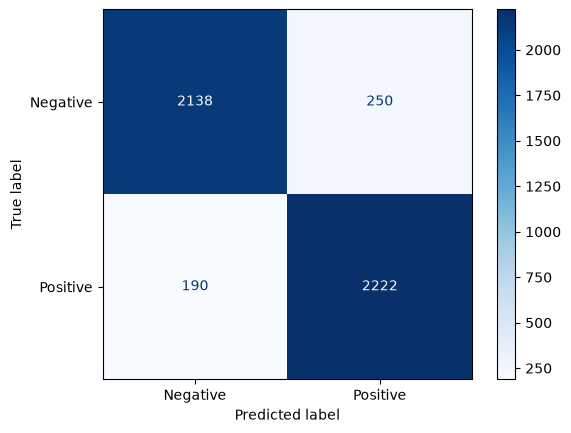

In [54]:
Y_pred_probs = model.predict(X_test)
Y_pred = (Y_pred_probs >= 0.5).astype(int).flatten()

cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

#### 2. Learning Curve (Accuracy & Loss)

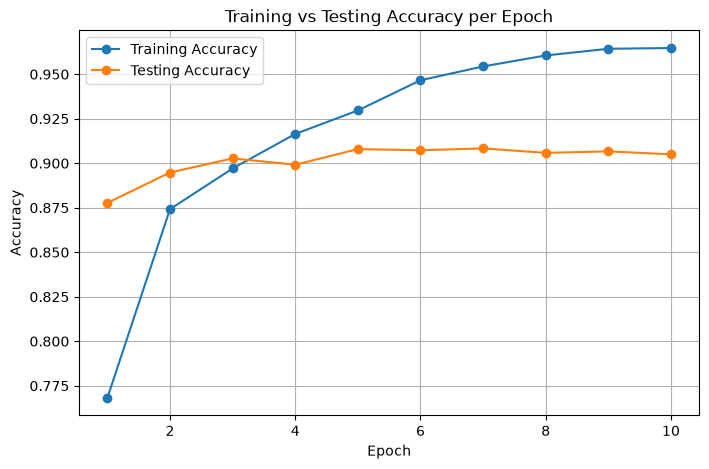

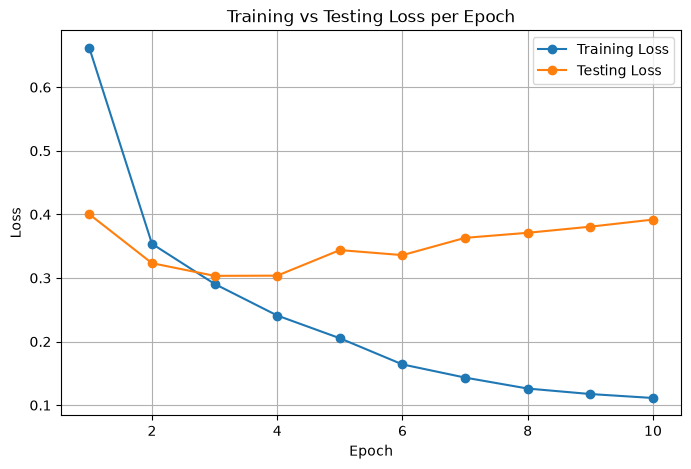

In [55]:
history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Testing Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Testing Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Testing Loss per Epoch')
plt.legend()
plt.grid(True)

plt.show()

#### 3. Determine best Epoch

In [56]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
print(f"Best epoch: {best_epoch}, val_accuracy: {best_val_acc:.4f}")

Best epoch: 7, val_accuracy: 0.9083


# Inference

In [57]:
def predict_sentiment(text, model, word_to_idx, max_len):
    cleaned = cleaning_text(text)
    casefolded = casefolding_text(cleaned)
    tokens = tokenizing_text(casefolded)
    tokens = stopword_text(tokens)
    tokens = lemming_text(tokens)

    sequence = [word_to_idx.get(word, 0) for word in tokens]
    padded = pad_sequences([sequence], maxlen=max_len, padding='post')

    prob = model.predict(padded, verbose=0)[0][0]
    label = 'positive' if prob >= 0.5 else 'negative'
    return label, prob

In [58]:
reviews = [
    "It wasn't bad, but I wouldn't watch it again.",
    "The acting was great but the plot made no sense.",
    "I expected to hate it but ended up really enjoying it.",
    "Not the worst movie I've seen, but far from the best.",
    "This was an absolute masterpiece from start to finish, I couldn't look away for a second.",
    "A complete waste of time, the plot made no sense and the acting was wooden.",
    "It was okay, nothing special but not terrible either.",
    "The visuals were stunning but the story dragged on way too long.",
    "I went in with low expectations and ended up pleasantly surprised."
]

for r in reviews:
    label, prob = predict_sentiment(r, model, word_to_idx, MAX_LEN)
    print(f"{r}\n  -> {label} ({prob:.3f})\n")

It wasn't bad, but I wouldn't watch it again.
  -> negative (0.024)

The acting was great but the plot made no sense.
  -> negative (0.136)

I expected to hate it but ended up really enjoying it.
  -> positive (0.930)

Not the worst movie I've seen, but far from the best.
  -> negative (0.007)

This was an absolute masterpiece from start to finish, I couldn't look away for a second.
  -> negative (0.024)

A complete waste of time, the plot made no sense and the acting was wooden.
  -> negative (0.000)

It was okay, nothing special but not terrible either.
  -> negative (0.002)

The visuals were stunning but the story dragged on way too long.
  -> positive (0.971)

I went in with low expectations and ended up pleasantly surprised.
  -> positive (0.950)

